# LoVoCCS morphology: Searching for patterns in morphology parameter space

This is a 'discovery science' portion of the X-LoVoCCS project, where we compile our various measurements of LoVoCCS cluster morphology (from the direct X-ray ICM measurements, and our comparisons with optical/WL constraints) into a single morphology parameter space and seek to identify any 'clusters of galaxy clusters'. 

**That is to say, are there distinct groupings of galaxy clusters in these morphology spaces, and do those groupings have physical meaning?**

While there are several hot intra-cluster medium (ICM) X-ray morphology metrics that we have not ___yet___ calculated (power ratios for instance; see [Rasia et al. 2013](https://ui.adsabs.harvard.edu/abs/2013AstRv...8a..40R/abstract), [Parekh et al. 2015](https://ui.adsabs.harvard.edu/abs/2015A%26A...575A.127P/abstract), and [Lovisari et al. 2017](https://ui.adsabs.harvard.edu/abs/2017ApJ...846...51L/abstract) for the review and application of a wide range of morphology metrics), we are in the almost unique position of having weak-lensing mass centroid and position angle information - this should help consider the whole system of a cluster, rather than just the ICM.

We have manually assigned some qualitative morphology class labels to the X-LoVoCCS sample, and we can take advantage of them here by looking to see whether groupings of points in different parameter spaces coincide with clusters of similar ICM morphology.

## Main takeaways 

In summary:

* 

## Import Statements

In [1]:
import pandas as pd
pd.set_option('display.max_columns', 500)
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import os
from astropy.units import Quantity
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AffinityPropagation, KMeans
from sklearn.manifold import TSNE

# This adds the directory above to the path, allowing me to import the common functions that I've written in
#  common.py - this just saves me repeating boring code and makes sure its all consistent
import sys
sys.path.insert(0, '../')
from common import lovoccs_cosmo

%matplotlib inline

## Useful values

Here we set up any values that are useful to several parts of the analysis in this notebook, and that we might wish to change in the future:

In [160]:
# These are the random states used for dimensionality reduction
umap_rand_state = 4059
tsne_rand_state = 907

# Overarching manual broad morphology classes 
BROAD_CLASS = {"CeP": "Centrally peaked", "R": "Regular", "S": "Structured", "LFB": "Largely featureless blob", 'MM': "Multi-modal"}
# Modifiers that can be applied to the broad classes
CLASS_MODIFIERS = {"Pl": "Central plateau", "SD": "Sharp drop", "Sp": "Spiral", "Ca": "Cavities", 
                   "OI": "Outer island", "NC{n}": "Number of components", 'PU': "Puffed up", 'Ta': "Tail", 
                   "BCP": "Bright central peaky"}

# Manual morphology class colours
CLASS_COLOURS = {'CeP': "darkslateblue", 'R': 'goldenrod', 'S': 'firebrick', 'LFB': 'purple', 'MM': 'fuchsia',
                  np.nan: 'black'}
# In an effort to make the histograms easier to interpret, we'll set up a linestyle for each class as well
CLASS_HIST_LS = {'CeP': "solid", 'R': 'dashed', 'S': 'dotted', 'LFB': 'dashdot', 'MM': 'dotted'}
# In the same vein, we'll give each class its own marker as well
CLASS_MARKERS = {'CeP': "d", 'R': '.', 'S': 'x', 'LFB': '+', 'MM': '2'}
# We also define some markers that will be plotted surrounding the main data points, with different shapes, to represent
#  the application of different modifiers
MOD_MARKERS = {'SD': 's', 'Sp': 'o', 'OI': 'p', 'PU': 'D', 'Ta': 'P', 'BCP': 'v'}
# And their sizes
MOD_MARKER_SIZE = {'SD': 100, 'Sp': 200, 'OI': 100, 'PU': 100, 'Ta': 100, 'BCP': 100}

## Output paths

Paths to save comparison figures and any output results files - defined here to avoid repetition and make the code easier to read: 

In [3]:
morph_fig_path = "../../outputs/figures/positions_and_morphology/morph_par_space/"
os.makedirs(morph_fig_path, exist_ok=True)

## Cosmological model

We employ the same cosmological model utilized in the LoVoCCS-I & II analyses (Fu et al. [2022](https://ui.adsabs.harvard.edu/abs/2022ApJ...933...84F/abstract), [2024](https://ui.adsabs.harvard.edu/abs/2024ApJ...974...69F/abstract)):

In [4]:
lovoccs_cosmo

LambdaCDM(name=None, H0=<Quantity 71. km / (Mpc s)>, Om0=0.2648, Ode0=0.7352, Tcmb0=<Quantity 0. K>, Neff=3.04, m_nu=None, Ob0=0.0448)

## Loading data files

Important considerations for this dataset:

* Some clusters selected for LoVoCCS have been identified as multiple blended systems in the course of the X-LoVoCCS project - other LoVoCCS works may only have entries/have made measurements for the overall system.
* Not all LoVoCCS-II galaxy clusters have XMM data available - as such we will not yet have measured X-ray centroids for them.
* The manually assigned morphology labels are subjective to some degree (though still useful) - the ICM morphology taxonomy that we use to label the clusters is also at an early stage, and will likely evolve in the future.

### X-LoVoCCS-I base sample

In [5]:
xlovoccs_base = pd.read_csv("../../sample_files/X-LoVoCCSI.csv")
xlovoccs_base.insert(0, 'name', xlovoccs_base['LoVoCCSID'].apply(lambda x: "LoVoCCS-" + str(x)))
xlovoccs_base.head(6)

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4
0,LoVoCCS-1,1,1,A2029,227.734300,5.745471,0.0766,1.3344,227.73000,5.720000,227.734300,5.745471,8.726709e+44
1,LoVoCCS-2,2,2,A401,44.740000,13.580000,0.0739,1.2421,44.74000,13.580000,NaN,NaN,6.088643e+44
2,LoVoCCS-4A,4A,4,A85North,10.458750,-9.301944,0.0555,1.2103,10.45875,-9.301944,NaN,NaN,5.100085e+44
3,LoVoCCS-4B,4B,4,A85South,10.451487,-9.460007,0.0555,1.2103,10.45875,-9.301944,10.451487,-9.460007,5.100085e+44
4,LoVoCCS-5,5,5,A3667,303.157313,-56.845978,0.0556,1.1990,303.13000,-56.830000,303.157313,-56.845978,4.871933e+44
5,LoVoCCS-7,7,7,A3827,330.480000,-59.950000,0.0980,1.1367,330.48000,-59.950000,NaN,NaN,4.204419e+44


### X-LoVoCCS-I manual morphology labels 

In [6]:
morphlab_path = "../../outputs/result_files/positions_and_morphology/manual_morphology_classification_modifiers_notes.csv"
xlovoccs_morphlab = pd.read_csv(morphlab_path).drop(columns=['LoVoCCSID', 'parent_LoVoCCSID'])
xlovoccs_morphlab.head(6)

,name,telescope_examined,SNR,examined_energy_band,proper_dist_resolution,morph_class,morph_class_modifiers,morph_notes
0,LoVoCCS-1,XMM,1686.73,0.5-2.0keV,6.24kpc/pix,CeP,NaN,NaN
1,LoVoCCS-2,XMM,310.37,0.5-2.0keV,6.04kpc/pix,S,+SD,SB discontinuity obvious to the bottom left (s...
2,LoVoCCS-4A,XMM,1958.89,0.5-2.0keV,4.63kpc/pix,CeP,+Pl+OI,"Two outer islands, one to the south (with irre..."
3,LoVoCCS-4B,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LoVoCCS-5,XMM,854.47,0.5-2.0keV,4.64kpc/pix,S,+SD+PU+Ta,"A3667, famously complicated morphology."
5,LoVoCCS-7,XMM,363.38,0.5-2.0keV,7.79kpc/pix,S,+SD,"Would have been 'R', but for the apparent shar..."


### X-LoVoCCS-I component alignments

Loads the difference between the ICM position angle, and the position angles of other cluster components:

In [7]:
xlovoccs_align = pd.read_csv("../../outputs/result_files/positions_and_morphology/icm_component_delta_pa_alignments.csv")
xlovoccs_align.head(6)

,name,icm_bcg_delta_pa,icm_rs500kpc_delta_pa,icm_wlm500kpc_delta_pa
0,LoVoCCS-1,-10.441,1.327,22.347
1,LoVoCCS-2,86.893,85.080,30.557
2,LoVoCCS-4B,49.458,23.340,-1.856
3,LoVoCCS-4A,8.683,-17.436,-42.632
4,LoVoCCS-5,-4.178,1.610,-70.978
5,LoVoCCS-7,29.208,28.755,23.426


### X-LoVoCCS-I component separations

The separation between centroids of the hot ICM and other cluster components, as a proper distance:

In [8]:
xlovoccs_sep = pd.read_csv("../../outputs/result_files/positions_and_morphology/icm_component_centroid_separations.csv")
xlovoccs_sep = xlovoccs_sep[['name', 'icm_bcg_kpc_sep', 'icm_red_seq_kpc_sep', 'icm_wlm_kpc_sep']]
xlovoccs_sep.head(6)

,name,icm_bcg_kpc_sep,icm_red_seq_kpc_sep,icm_wlm_kpc_sep
0,LoVoCCS-1,7.91714,146.28484,166.73691
1,LoVoCCS-2,34.08941,31.61540,35.16104
2,LoVoCCS-4B,495.63413,511.23794,390.91215
3,LoVoCCS-4A,4.27954,212.94495,117.29874
4,LoVoCCS-5,116.02293,34.77165,36.36157
5,LoVoCCS-7,52.55452,70.92831,127.60351


We also load the separations of the ICM and other components parallel and perpendicular to the ICM PA:

In [9]:
xlovoccs_para_perp_sep = pd.read_csv("../../outputs/result_files/positions_and_morphology/"\
                                     "icm_component_centroid_parallel-perpendicular_separations.csv")
xlovoccs_para_perp_sep.head(6)

,name,para_icm_bcg_kpc_sep,perp_icm_bcg_kpc_sep,para_icm_red_seq_kpc_sep,perp_icm_red_seq_kpc_sep,para_icm_wlm_kpc_sep,perp_icm_wlm_kpc_sep
0,LoVoCCS-1,7.90391,-0.45754,146.14163,-6.47207,157.00254,56.13731
1,LoVoCCS-2,8.33723,33.05429,24.31311,20.20944,11.93968,33.07193
2,LoVoCCS-4B,467.58353,164.37407,368.28099,354.58955,347.08944,179.83675
3,LoVoCCS-4A,-3.45646,2.52338,-52.48558,-206.37628,77.69232,-87.88015
4,LoVoCCS-5,-110.52595,-35.33815,21.15631,27.60117,0.62357,-36.35839
5,LoVoCCS-7,-1.82102,52.53148,70.43515,-8.35951,10.64052,127.17875


### X-LoVoCCS-I morphologies

Common morphology metrics for X-ray emission from galaxy clusters, the centroid shift and concentration: 

In [10]:
xlovoccs_morph = pd.read_csv("../../outputs/result_files/positions_and_morphology/xmm_centshift_concentration.csv")
xlovoccs_morph.head(6)

,name,cen_shift,cen_shift-,cen_shift+,concentration,concentration-,concentration+
0,LoVoCCS-1,0.0057,0.0001,0.0001,0.4412,0.0004,0.0004
1,LoVoCCS-2,0.0660,0.0007,0.0006,0.1640,0.0019,0.0015
2,LoVoCCS-4A,NaN,NaN,NaN,NaN,NaN,NaN
3,LoVoCCS-4B,NaN,NaN,NaN,NaN,NaN,NaN
4,LoVoCCS-5,0.0815,0.0004,0.0004,0.1245,0.0005,0.0005
5,LoVoCCS-7,0.0417,0.0009,0.0010,0.2387,0.0017,0.0019


### X-LoVoCCS-I axis ratios

This file contains the axis length ratios of the elliptical representation of the hot ICM used for X-ray centroid and ICM PA measurement:

In [11]:
xlovoccs_axrat = pd.read_csv("../../outputs/result_files/positions_and_morphology/xmm_500kpc_centroid_posang.csv")
xlovoccs_axrat = xlovoccs_axrat[['name', 'ax_ratio', 'ax_ratio-', 'ax_ratio+']]
xlovoccs_axrat.head(6)

,name,ax_ratio,ax_ratio-,ax_ratio+
0,LoVoCCS-1,0.9202,0.0011,0.0012
1,LoVoCCS-2,0.9746,0.0049,0.0043
2,LoVoCCS-4A,0.8910,0.0009,0.0010
3,LoVoCCS-4B,0.9176,0.0047,0.0038
4,LoVoCCS-5,0.8262,0.0011,0.0012
5,LoVoCCS-7,0.9519,0.0032,0.0037


### Combining tables

In [12]:
xlovoccs_samp = pd.merge(xlovoccs_base, xlovoccs_align, left_on='name', right_on='name', how='outer')
xlovoccs_samp = pd.merge(xlovoccs_samp, xlovoccs_morphlab, left_on='name', right_on='name', how='outer')
xlovoccs_samp = pd.merge(xlovoccs_samp, xlovoccs_sep, left_on='name', right_on='name', how='outer')
xlovoccs_samp = pd.merge(xlovoccs_samp, xlovoccs_para_perp_sep, left_on='name', right_on='name', how='outer')
xlovoccs_samp = pd.merge(xlovoccs_samp, xlovoccs_morph, left_on='name', right_on='name', how='outer')
xlovoccs_samp = pd.merge(xlovoccs_samp, xlovoccs_axrat, left_on='name', right_on='name', how='outer')
xlovoccs_samp = xlovoccs_samp.sort_values('parent_LoVoCCSID').reset_index(drop=True)
xlovoccs_samp

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4,icm_bcg_delta_pa,icm_rs500kpc_delta_pa,icm_wlm500kpc_delta_pa,telescope_examined,SNR,examined_energy_band,proper_dist_resolution,morph_class,morph_class_modifiers,morph_notes,icm_bcg_kpc_sep,icm_red_seq_kpc_sep,icm_wlm_kpc_sep,para_icm_bcg_kpc_sep,perp_icm_bcg_kpc_sep,para_icm_red_seq_kpc_sep,perp_icm_red_seq_kpc_sep,para_icm_wlm_kpc_sep,perp_icm_wlm_kpc_sep,cen_shift,cen_shift-,cen_shift+,concentration,concentration-,concentration+,ax_ratio,ax_ratio-,ax_ratio+
0,LoVoCCS-1,1,1,A2029,227.734300,5.745471,0.0766,1.3344,227.73000,5.720000,227.734300,5.745471,8.726709e+44,-10.441,1.327,22.347,XMM,1686.73,0.5-2.0keV,6.24kpc/pix,CeP,NaN,NaN,7.91714,146.28484,166.73691,7.90391,-0.45754,146.14163,-6.47207,157.00254,56.13731,0.0057,0.0001,0.0001,0.4412,0.0004,0.0004,0.9202,0.0011,0.0012
1,LoVoCCS-2,2,2,A401,44.740000,13.580000,0.0739,1.2421,44.74000,13.580000,NaN,NaN,6.088643e+44,86.893,85.080,30.557,XMM,310.37,0.5-2.0keV,6.04kpc/pix,S,+SD,SB discontinuity obvious to the bottom left (s...,34.08941,31.61540,35.16104,8.33723,33.05429,24.31311,20.20944,11.93968,33.07193,0.0660,0.0007,0.0006,0.1640,0.0019,0.0015,0.9746,0.0049,0.0043
2,LoVoCCS-4B,4B,4,A85South,10.451487,-9.460007,0.0555,1.2103,10.45875,-9.301944,10.451487,-9.460007,5.100085e+44,49.458,23.340,-1.856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,495.63413,511.23794,390.91215,467.58353,164.37407,368.28099,354.58955,347.08944,179.83675,NaN,NaN,NaN,NaN,NaN,NaN,0.9176,0.0047,0.0038
3,LoVoCCS-4A,4A,4,A85North,10.458750,-9.301944,0.0555,1.2103,10.45875,-9.301944,NaN,NaN,5.100085e+44,8.683,-17.436,-42.632,XMM,1958.89,0.5-2.0keV,4.63kpc/pix,CeP,+Pl+OI,"Two outer islands, one to the south (with irre...",4.27954,212.94495,117.29874,-3.45646,2.52338,-52.48558,-206.37628,77.69232,-87.88015,NaN,NaN,NaN,NaN,NaN,NaN,0.8910,0.0009,0.0010
4,LoVoCCS-5,5,5,A3667,303.157313,-56.845978,0.0556,1.1990,303.13000,-56.830000,303.157313,-56.845978,4.871933e+44,-4.178,1.610,-70.978,XMM,854.47,0.5-2.0keV,4.64kpc/pix,S,+SD+PU+Ta,"A3667, famously complicated morphology.",116.02293,34.77165,36.36157,-110.52595,-35.33815,21.15631,27.60117,0.62357,-36.35839,0.0815,0.0004,0.0004,0.1245,0.0005,0.0005,0.8262,0.0011,0.0012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,LoVoCCS-121,121,121,A3128,52.466189,-52.580728,0.0624,0.8831,52.50000,-52.600000,52.466189,-52.580728,1.101682e+44,30.510,36.135,30.219,XMM,290.09,0.5-2.0keV,5.16kpc/pix,MM,+NC2+PU+OI,"Fairly straightforward multi-modal morphology,...",786.07889,595.70455,728.07991,364.94125,-696.33997,452.86306,-387.12723,608.71878,-399.60782,0.0813,0.0010,0.0008,0.1874,0.0015,0.0015,0.9639,0.0049,0.0054
63,LoVoCCS-122,122,122,A1023,157.000000,-6.800000,0.1176,0.8553,157.00000,-6.800000,NaN,NaN,1.095941e+44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
64,LoVoCCS-123,123,123,A3528,193.670000,-29.220000,0.0544,0.8855,193.67000,-29.220000,NaN,NaN,1.093054e+44,-35.663,-36.921,-39.858,XMM,151.62,0.5-2.0keV,4.54kpc/pix,CeP,NaN,NaN,870.22781,907.54168,886.64398,-840.23097,226.53062,-873.89086,244.85642,-835.66870,296.31146,0.0184,0.0005,0.0006,0.5663,0.0035,0.0037,0.9249,0.0117,0.0113
65,LoVoCCS-131,131,131,A761,137.651250,-10.581111,0.0916,0.8627,137.65125,-10.581111,NaN,NaN,1.063423e+44,-9.562,-43.609,47.092,XMM,100.18,0.5-2.0keV,7.33kpc/pix,LFB,NaN,NaN,11.09012,195.02436,43.41697,-10.81259,2.46576,184.83225,-62.22478,-36.75744,-23.10703,0.0125,0.0017,0.0018,0.1932,0.0050,0.0058,0.9575,0.0145,0.0125


## Morphology parameter space visualisation

Here we visualize the X-LoVoCCS morphology parameter space, combining our direct measurements of hot ICM morphology, and the component position angle alignment/centroid separations we have calculated in concert with the LoVoCCS-II optical/weak-lensing analysis. 

We do not necessarily include every parameter we measure in the visualisation, as some are slightly degenerate (the parallel/perpendicular to hot ICM PA separations, and the overall Haversine-calculated separations for instance).

### Configuring plot

In [13]:
# par_names = ['icm_bcg_delta_pa', 'icm_rs500kpc_delta_pa', 'icm_wlm500kpc_delta_pa', 
#              'icm_bcg_kpc_sep', 'icm_red_seq_kpc_sep', 'icm_wlm_kpc_sep', 
#              'para_icm_bcg_kpc_sep', 'perp_icm_bcg_kpc_sep', 
#              'para_icm_red_seq_kpc_sep', 'perp_icm_red_seq_kpc_sep', 
#              'para_icm_wlm_kpc_sep', 'perp_icm_wlm_kpc_sep', 
#              'cen_shift', 'concentration', 'ax_ratio']

par_names = ['icm_bcg_delta_pa', 'icm_rs500kpc_delta_pa', 'icm_wlm500kpc_delta_pa', 
             'icm_bcg_kpc_sep', 
             'icm_red_seq_kpc_sep', 
             'icm_wlm_kpc_sep',
             'cen_shift', 'concentration', 'ax_ratio']

# Nice labels for the different parameters
par_labels = {'icm_bcg_delta_pa': r"$\Delta\theta_{\rm{ICM-BCG}}$ [deg]",
              'icm_rs500kpc_delta_pa': r"$\Delta\theta_{\rm{ICM-RS}}$ [deg]",
              'icm_wlm500kpc_delta_pa': r"$\Delta\theta_{\rm{ICM-WLM}}$ [deg]",
              'icm_bcg_kpc_sep': r"$\Delta C_{\rm{ICM-BCG}}$ [kpc]",
              'icm_red_seq_kpc_sep': r"$\Delta C_{\rm{ICM-RS}}$ [kpc]",
              'icm_wlm_kpc_sep': r"$\Delta C_{\rm{ICM-WLM}}$ [kpc]",
              'cen_shift': r"$w$",
              'concentration': r"$c$",
              'ax_ratio': r"ICM$_{\rm{a\!:\!b}}$"}

# Binning for different parameter histograms
par_bins = {'icm_bcg_delta_pa': np.arange(-90, 90+20, 20),
            'icm_rs500kpc_delta_pa': np.arange(-90, 90+20, 20),
            'icm_wlm500kpc_delta_pa': np.arange(-90, 90+20, 20),
            'icm_bcg_kpc_sep': np.arange(0, 1200+75, 75),
            'icm_red_seq_kpc_sep': np.arange(0, 1200+75, 75),
            'icm_wlm_kpc_sep': np.arange(0, 1200+75, 75),
            'cen_shift': np.arange(0, 0.1+0.01, 0.01),
            'concentration': np.arange(0, 1+0.05, 0.05),
            'ax_ratio': np.arange(0.65, 1+0.05, 0.05)}

### Corner plot

We make two versions of the morphology parameter space corner plot - one that just shows all data points and histograms in a single colour, and another that colours them by the manually assigned morphology label for each cluster:

#### Overall corner plot

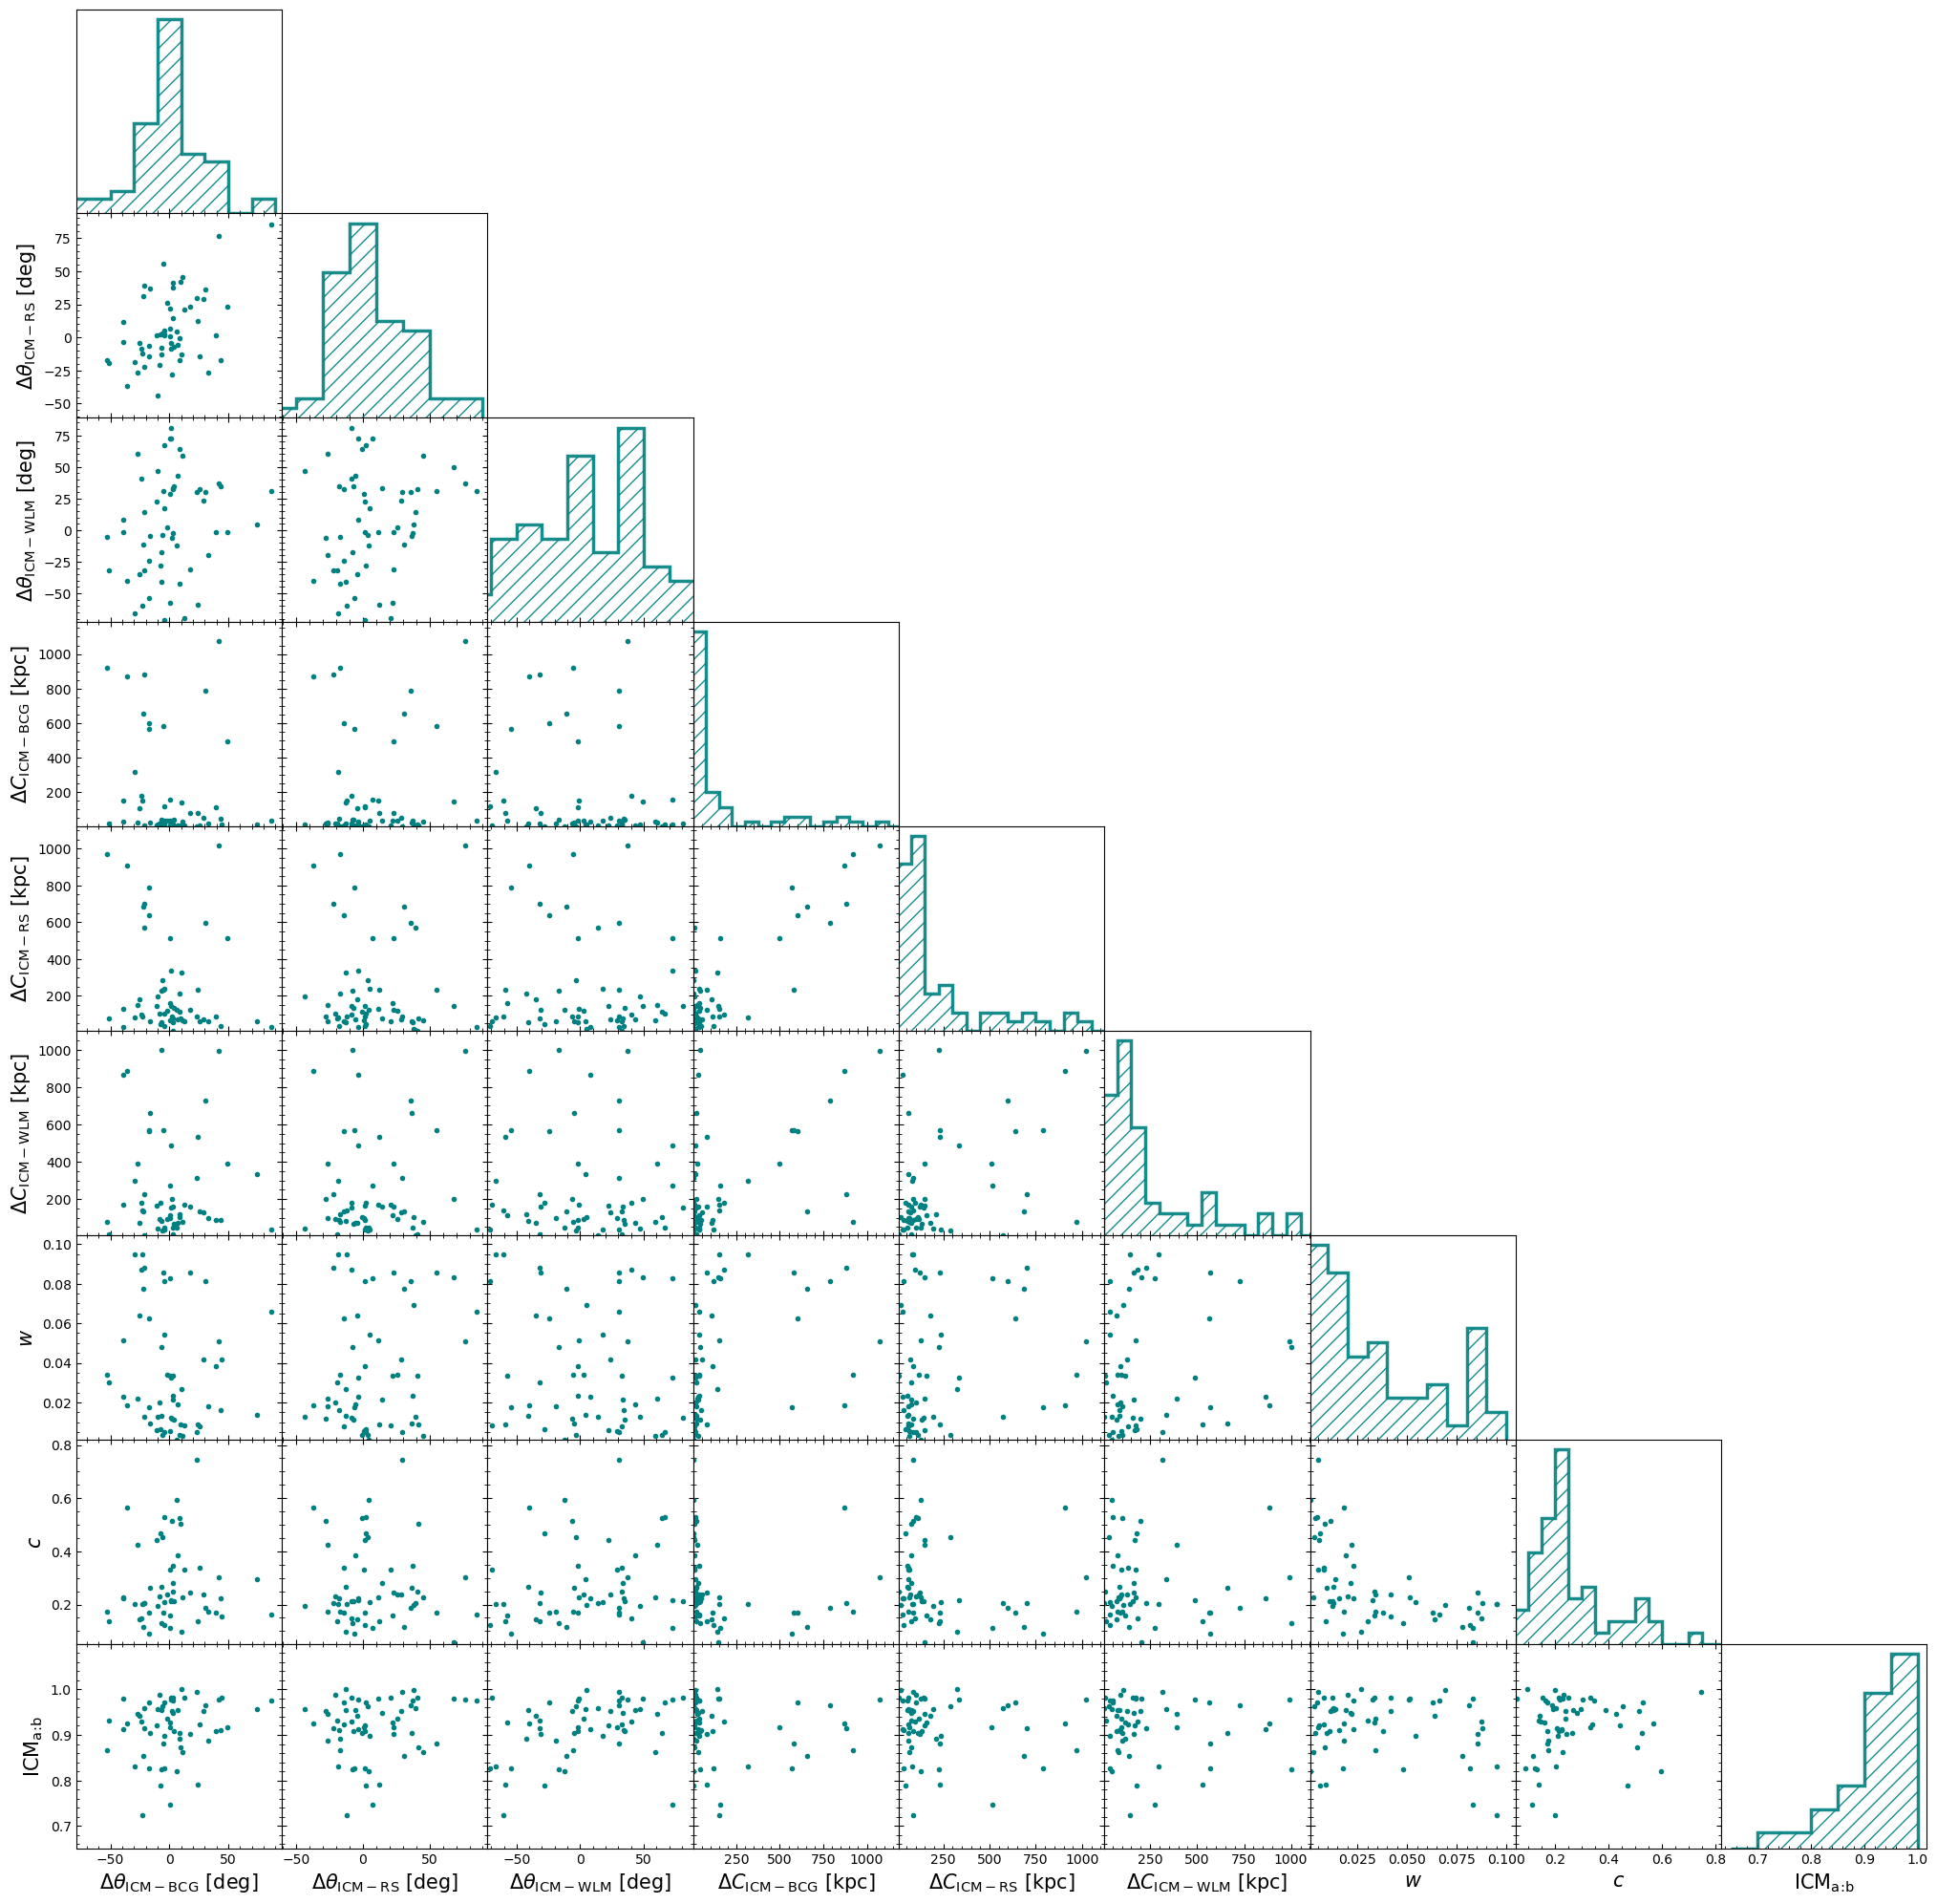

In [14]:
# Fraction to go either side of the min/max of a given parameter distribution
limit_padding = 0.1

# Colour to use globally for these data
glob_colour = "teal"
hist_colour = "teal"

fig, ax_arr = plt.subplots(figsize=(25, 25), sharex=False, sharey=False, ncols=len(par_names), nrows=len(par_names))
fig.subplots_adjust(hspace=0)
fig.subplots_adjust(wspace=0)

lims = np.vstack([np.nanmin(xlovoccs_samp[par_names].values, axis=0)*(1-limit_padding), 
                  np.nanmax(xlovoccs_samp[par_names].values, axis=0)*(1+limit_padding)]).T

for m, subplot in np.ndenumerate(ax_arr):
    cur_x_par_name = par_names[m[1]]
    cur_y_par_name = par_names[m[0]]

    cur_x_vals = xlovoccs_samp[cur_x_par_name].values
    cur_y_vals = xlovoccs_samp[cur_y_par_name].values

    cur_x_lims = lims[m[1], :]
    cur_y_lims = lims[m[0], :]
    
    if m[0] < m[1]:
        subplot.axis('off')
        
    elif m[0] > m[1]:
        subplot.minorticks_on()
        subplot.tick_params(axis='both', direction='in', which='both', top=True, right=True)

        ax_arr[m].plot(cur_x_vals, cur_y_vals, '.', color=glob_colour)

        ax_arr[m].set_xlim(cur_x_lims)
        ax_arr[m].set_ylim(cur_y_lims)
        
        if m[0] == (len(par_names) - 1):
            ax_arr[m].set_xlabel(par_labels[cur_x_par_name], fontsize=15)
            ax_arr[m].sharex(ax_arr[(m[0]-1, m[1])])
        # else:
            # ax_arr[m].set_xticks(ax_arr[m].get_xticks(), [])
        
        # Setting up the y-axis ticks for rows
        if m[1] == 0:
            ax_arr[m].set_ylabel(par_labels[cur_y_par_name], fontsize=15)
        elif m[1] != 0:
            ax_arr[m].sharey(ax_arr[(m[0], m[1]-1)])
            # ax_arr[m].set_yticks(ax_arr[m].get_yticks(), [])
            plt.setp(ax_arr[m].get_yticklabels(), visible=False)   

    elif m[0] == m[1]:
        subplot.minorticks_on()
        subplot.tick_params(axis='both', direction='in', which='both', top=False, right=False, left=False)

        if m[0] != (len(par_names) - 1):
            ax_arr[m].sharex(ax_arr[(m[0]+1, m[1])])

        # Overall distributions
        ax_arr[m].hist(cur_x_vals, bins=par_bins[cur_x_par_name], alpha=0.9, density=True, color=hist_colour, 
                       histtype='step', linewidth=2.5, hatch='//')

        ax_arr[m].set_yticks([])
        
        if m[0] == (len(par_names) - 1):
            ax_arr[m].set_xlabel(par_labels[cur_x_par_name], fontsize=15)

# fig.suptitle("X-LoVoCCS Morphology Parameter Space", fontsize=30, y=0.89, ha="center")
plt.savefig(morph_fig_path + "xlovoccs_morph_par_space_corner.pdf", bbox_inches='tight')
plt.show()

#### Coloured by manually assigned morphology class

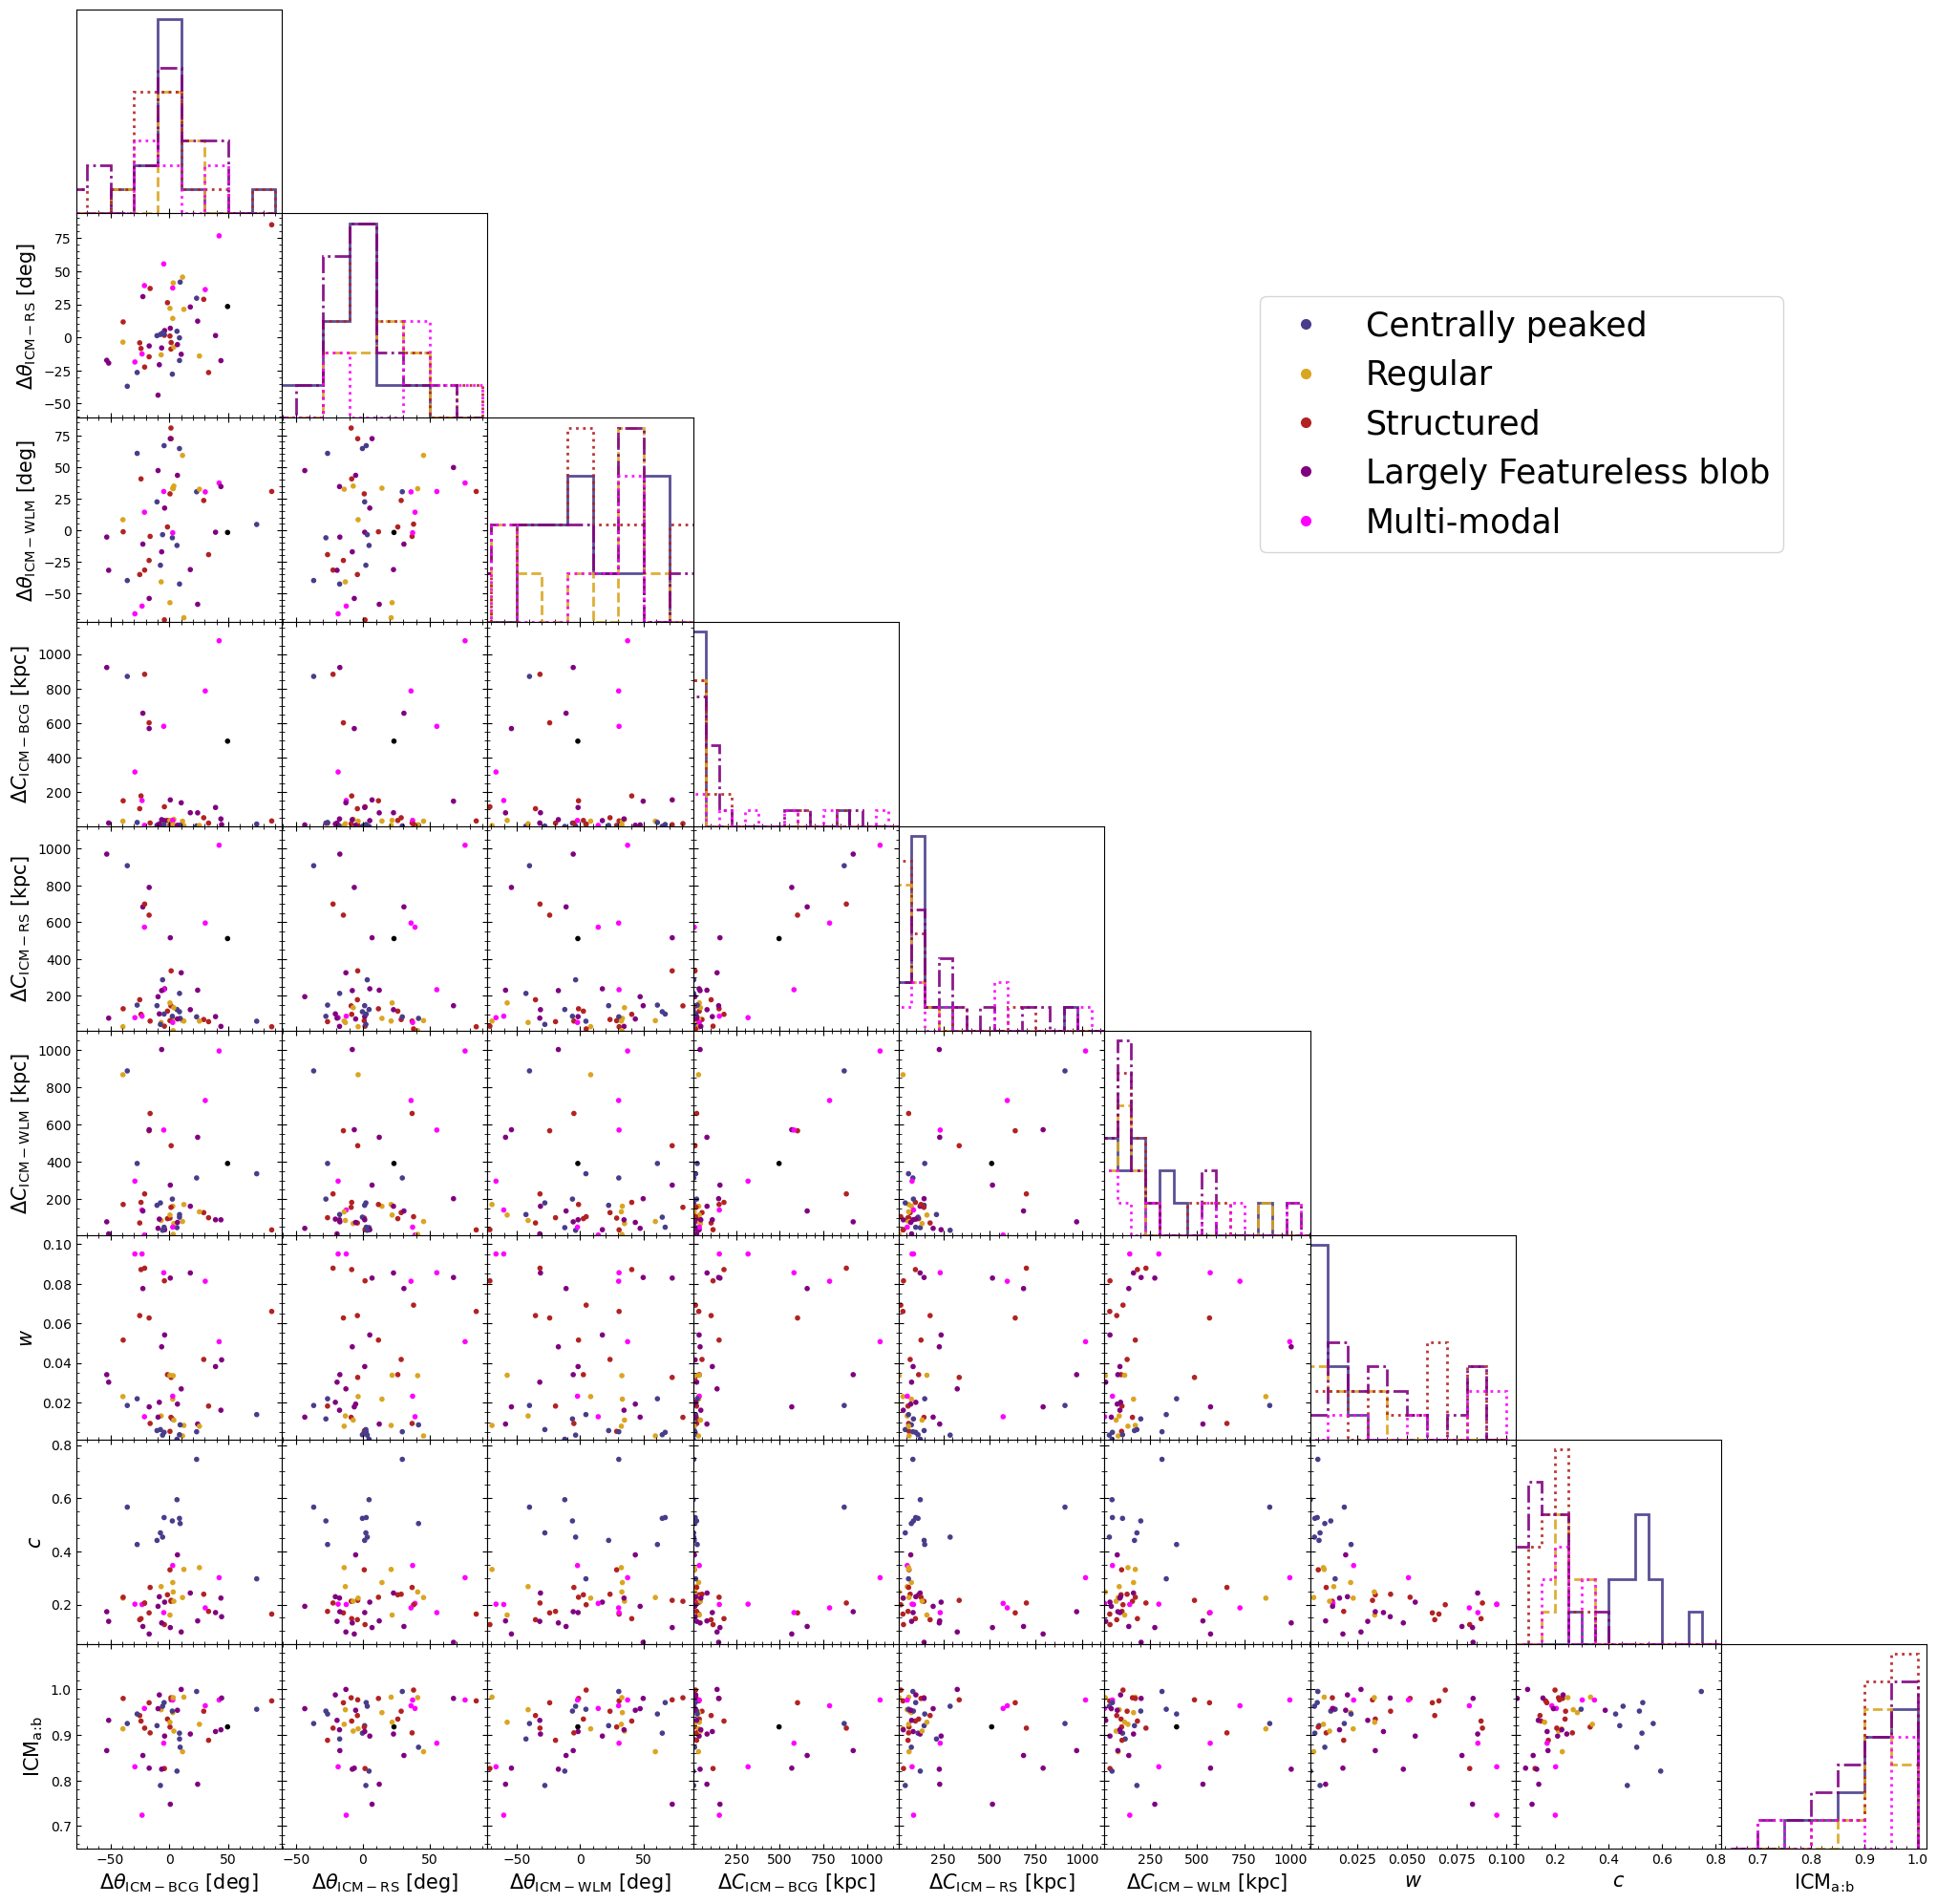

In [15]:
# Fraction to go either side of the min/max of a given parameter distribution
limit_padding = 0.1

# Set up the colour of each data point based on the class colours
point_colours = np.array([CLASS_COLOURS[mc] for mc in xlovoccs_samp['morph_class'].values])

fig, ax_arr = plt.subplots(figsize=(25, 25), sharex=False, sharey=False, ncols=len(par_names), nrows=len(par_names))
fig.subplots_adjust(hspace=0)
fig.subplots_adjust(wspace=0)

lims = np.vstack([np.nanmin(xlovoccs_samp[par_names].values, axis=0)*(1-limit_padding), 
                  np.nanmax(xlovoccs_samp[par_names].values, axis=0)*(1+limit_padding)]).T

for m, subplot in np.ndenumerate(ax_arr):
    cur_x_par_name = par_names[m[1]]
    cur_y_par_name = par_names[m[0]]

    cur_x_vals = xlovoccs_samp[cur_x_par_name].values
    cur_y_vals = xlovoccs_samp[cur_y_par_name].values

    cur_x_lims = lims[m[1], :]
    cur_y_lims = lims[m[0], :]
    
    if m[0] < m[1]:
        subplot.axis('off')
        
    elif m[0] > m[1]:
        subplot.minorticks_on()
        subplot.tick_params(axis='both', direction='in', which='both', top=True, right=True)

        ax_arr[m].scatter(cur_x_vals, cur_y_vals, marker='.', c=point_colours)
        # Trying out different markers for each morph class
        # for sh_cl, rel_mark in CLASS_MARKERS.items():
        #     # Get the current parameter data for just the current broad manual morphology classification
        #     rel_pnt_msk = xlovoccs_samp['morph_class'].values == sh_cl
        #     ax_arr[m].scatter(cur_x_vals[rel_pnt_msk], cur_y_vals[rel_pnt_msk], marker=rel_mark, c=point_colours[rel_pnt_msk])

        ax_arr[m].set_xlim(cur_x_lims)
        ax_arr[m].set_ylim(cur_y_lims)
        
        # Setting up the x-axis ticks for columns
        if m[0] == (len(par_names) - 1):
            ax_arr[m].set_xlabel(par_labels[cur_x_par_name], fontsize=15)
            ax_arr[m].sharex(ax_arr[(m[0]-1, m[1])])
        else:
            pass
            # ax_arr[m].set_xticks(ax_arr[m].get_xticks(), [])

        # Setting up the y-axis ticks for rows
        if m[1] == 0:
            ax_arr[m].set_ylabel(par_labels[cur_y_par_name], fontsize=15)
        elif m[1] != 0:
            ax_arr[m].sharey(ax_arr[(m[0], m[1]-1)])
            # ax_arr[m].set_yticks(ax_arr[m].get_yticks(), [])
            plt.setp(ax_arr[m].get_yticklabels(), visible=False)     

    elif m[0] == m[1]:
        subplot.minorticks_on()
        subplot.tick_params(axis='both', direction='in', which='both', top=False, right=False, left=False)

        if m[0] != (len(par_names) - 1):
            ax_arr[m].sharex(ax_arr[(m[0]+1, m[1])])

        # Plots the parameter histograms of different morphology class clusters separately
        for sh_cl in BROAD_CLASS:
            # Get the current parameter data for just the current broad manual morphology classification
            rel_pnts = cur_x_vals[xlovoccs_samp['morph_class'].values == sh_cl]
            # And make the histogram for the current parameter and the current morph class
            ax_arr[m].hist(rel_pnts, bins=par_bins[cur_x_par_name], alpha=0.9, density=False, color=CLASS_COLOURS[sh_cl], 
                       histtype='step', linewidth=2, linestyle=CLASS_HIST_LS[sh_cl])
        
        ax_arr[m].set_yticks([])
        
        if m[0] == (len(par_names) - 1):
            ax_arr[m].set_xlabel(par_labels[cur_x_par_name], fontsize=15)

# Add a legend linking the point colours to the manual morphology class - we'll use more descriptive class names than 
#  the short ones stored in the classification table though
# First step is to set up a bunch of dummy matplotlib objects
leg_arts = [Line2D([0], [0], marker='.', color=cl_col, label=BROAD_CLASS[sh_cl], markersize=14, linewidth=0) 
            for sh_cl, cl_col in CLASS_COLOURS.items() if sh_cl is not np.nan]
fig.legend(handles=leg_arts, loc=(0.65, 0.71), fontsize=25)

# fig.suptitle("X-LoVoCCS Morphology Parameter Space", fontsize=30, y=0.89, ha="center")
plt.savefig(morph_fig_path + "xlovoccs_morph_par_space_corner-manual_morph_class_colours.pdf", bbox_inches='tight')
plt.show()

## Dimensionality reduction

To search for patterns, or similar galaxy clusters, in a semi-high dimensional parameter space, it can be useful to reduce the dimensionality of the data. There are numerous different methods that can be used to project N dimensional data into a 2D parameter space (embedding the data), we will quickly apply a few common approaches.

First, we prepare the data that we wish to use, dropping any galaxy clusters that have NaN entries for any parameters - we also use a scaling tool that transforms the input data to have mean of zero, and variance of one, as some machine-learning approaches require this.

In [89]:
# Make a copy of the relevant information we have loaded in
all_data = xlovoccs_samp[['name', 'morph_class', 'morph_class_modifiers'] + par_names].copy()
all_data = all_data.dropna(subset=par_names)

# Read out the names (we do this because we dropped nan entries from the X-LoVoCCS sample df, so we 
#  can't just read the names out of there)
rel_names = all_data['name'].values
del all_data['name']

# And read out the morphology labels we manually assigned
rel_morph_class = all_data['morph_class'].values
del all_data['morph_class']

# And read out the modifiers we may have assigned to the broader morphology class
rel_morph_mods = all_data['morph_class_modifiers'].values
del all_data['morph_class_modifiers']

all_data = all_data.values

scaled_data = StandardScaler().fit_transform(all_data)

### UMAP

Apparently UMAP can be sensitive to non-normalised data, so here we make use of the 'standard-scaled' parameter space:

In [77]:
umap_dim_red = umap.UMAP(random_state=umap_rand_state)
umap_reduced = umap_dim_red.fit_transform(scaled_data)

/Users/dt237/software/anaconda3/envs/xga_latest/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/dt237/software/anaconda3/envs/xga_latest/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


We will now visualise the new 2D embedding of our morphology parameter space - examining the structure of the embedding may lead us to find groups of galaxy clusters that are somehow similar. We can also colour/shape the points by the broad morphology class we manually assigned them: 

/var/folders/td/gw9qkx6d3szb1nkt_cfvcbzm000vzl/T/ipykernel_46752/3025820545.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rel_data_msk =  pd.Series(rel_morph_mods).str.contains(morph_mod).replace(np.nan, False).values


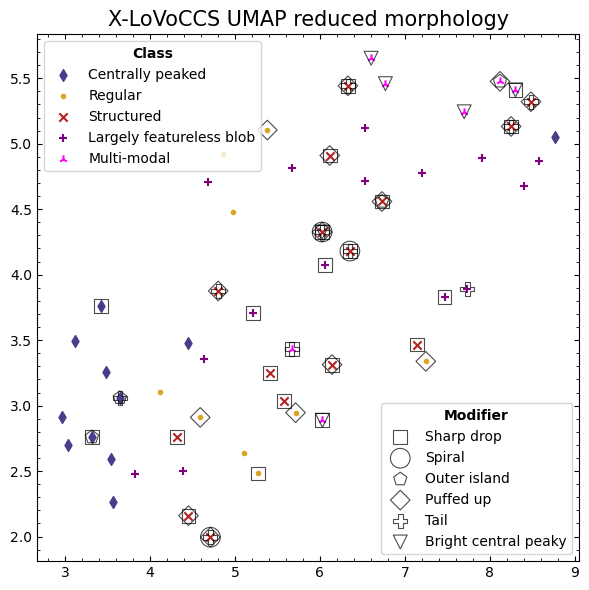

In [165]:
plt.figure(figsize=(6, 6))
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

class_leg_hands = []
for morph_class, rel_marker in CLASS_MARKERS.items():
    rel_data_msk = rel_morph_class == morph_class
    cur_class_sc = plt.scatter(umap_reduced[rel_data_msk, 0], umap_reduced[rel_data_msk, 1], 
                               c=CLASS_COLOURS[morph_class], marker=rel_marker, 
                               label=BROAD_CLASS[morph_class])
    # For the class legend
    class_leg_hands.append(cur_class_sc)

mod_leg_hands = []
for morph_mod, rel_marker in MOD_MARKERS.items():
    rel_data_msk =  pd.Series(rel_morph_mods).str.contains(morph_mod).replace(np.nan, False).values

    # c=CLASS_COLOURS[morph_class]
    cur_mod_sc = plt.scatter(umap_reduced[rel_data_msk, 0], umap_reduced[rel_data_msk, 1], 
                             marker=rel_marker, label=CLASS_MODIFIERS[morph_mod], fc='none', ec='black', 
                             s=MOD_MARKER_SIZE[morph_mod], lw=0.8, alpha=0.7)
    # For the modifire legend
    mod_leg_hands.append(cur_mod_sc)

# Legend describing how point shape/color relates to broad class
class_legend = plt.gca().legend(handles=class_leg_hands, loc='upper left', title='Class', title_fontproperties={'weight':'bold'})
# And the modifier marker legend
mod_legend = plt.gca().legend(handles=mod_leg_hands, loc='lower right', title='Modifier', title_fontproperties={'weight':'bold'})
plt.gca().add_artist(class_legend)

# Set the figure title
plt.title("X-LoVoCCS UMAP reduced morphology", fontsize=15)
# Remove any extraneous white space
plt.tight_layout()
plt.savefig(morph_fig_path + "xlovoccs_umap_reduced_parspace.pdf")
plt.show()

### t-SNE

This technique is apparently less sensitive to the data being normalised/scaled, so we try using the original morphology parameter space:

In [19]:
tsne_dim_red = TSNE(perplexity=5, random_state=tsne_rand_state)
tsne_reduced = tsne_dim_red.fit_transform(all_data)

#### Visualization and manual identification of possible point clusters

We once again visualize the 2D embedding of the morphology parameter space, for the same reasons. In this instance, we note that there appear to be some more distinctive groups of data points. In theory these data points should be close to one another in the multi-dimensional morphology parameter space - we highlight several groups of data points identified by eye:

In [67]:
tsne_manual_assoc_bnds = {'1': {'bnd': [[-28, -14], [-42, -28]], 'color': 'teal'},
                          '2': {'bnd': [[-16, -7], [-16, -8]], 'color': 'firebrick'},
                          '3': {'bnd': [[23, 32], [-20, 0]], 'color': 'peru'}
                         }

tsne_manual_assoc_inds = {}
# Sometimes it is just easier to write a for loop
for assoc_name, assoc_info in tsne_manual_assoc_bnds.items():
    assoc_bnds = assoc_info['bnd']
    cur_inds = np.argwhere(((tsne_reduced[:, 0] <=assoc_bnds[0][1]) & (tsne_reduced[:, 0] > assoc_bnds[0][0])) &
                           ((tsne_reduced[:, 1] <=assoc_bnds[1][1]) & (tsne_reduced[:, 1] > assoc_bnds[1][0]))).flatten()
    tsne_manual_assoc_inds[assoc_name] = cur_inds

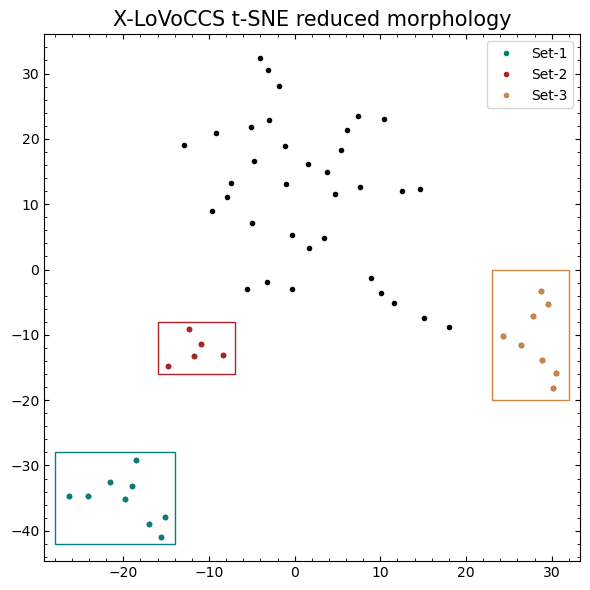

In [68]:
plt.figure(figsize=(6, 6))
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)
plt.plot(tsne_reduced[:, 0], tsne_reduced[:, 1], '.', color='black')

for assoc_name, assoc_info in tsne_manual_assoc_bnds.items():
    assoc_bnds = assoc_info['bnd']
    cur_assoc_inds = tsne_manual_assoc_inds[assoc_name]
    
    cur_rect = Rectangle([assoc_bnds[0][0], assoc_bnds[1][0]], 
                         assoc_bnds[0][1]-assoc_bnds[0][0],
                         assoc_bnds[1][1]-assoc_bnds[1][0],
                         fc='none', ec=assoc_info['color'])
    plt.gca().add_artist(cur_rect)

    # Bit wasteful, but I'll just plot over those data points
    
    plt.plot(tsne_reduced[cur_assoc_inds, 0], tsne_reduced[cur_assoc_inds, 1], '.', color=assoc_info['color'], 
             label="Set-"+assoc_name)

plt.title('X-LoVoCCS t-SNE reduced morphology', fontsize=15)

plt.legend()
plt.tight_layout()
plt.show()

Names of the clusters selected in each set:

In [69]:
for assoc_name, assoc_inds in tsne_manual_assoc_inds.items():
    print("Set-" + assoc_name)
    for lov_name in rel_names[assoc_inds]:
        print(lov_name)
    print('')

Set-1
LoVoCCS-11
LoVoCCS-41B
LoVoCCS-46B
LoVoCCS-48B
LoVoCCS-60A
LoVoCCS-66B
LoVoCCS-93B
LoVoCCS-121
LoVoCCS-123

Set-2
LoVoCCS-9
LoVoCCS-46C
LoVoCCS-46A
LoVoCCS-61
LoVoCCS-65

Set-3
LoVoCCS-24
LoVoCCS-39
LoVoCCS-41A
LoVoCCS-45
LoVoCCS-51
LoVoCCS-60B
LoVoCCS-75
LoVoCCS-93A



#### Visualization with manual morphology class labels

We'll now visualize the same reduced parameter space, in the same way, but colouring/shaping data points by the broad morphology class we manually assigned to them in another part of this project:

/var/folders/td/gw9qkx6d3szb1nkt_cfvcbzm000vzl/T/ipykernel_46752/3054342621.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  rel_data_msk =  pd.Series(rel_morph_mods).str.contains(morph_mod).replace(np.nan, False).values


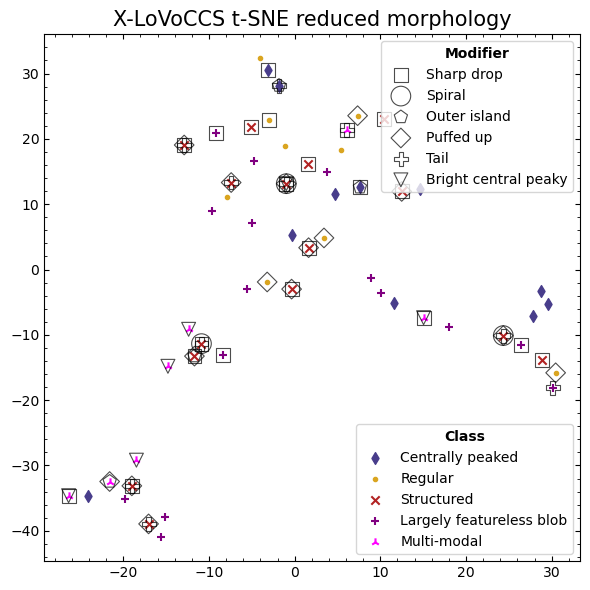

In [171]:
plt.figure(figsize=(6, 6))
plt.minorticks_on()
plt.tick_params(which='both', direction='in', top=True, right=True)

class_leg_hands = []
for morph_class, rel_marker in CLASS_MARKERS.items():
    rel_data_msk = rel_morph_class == morph_class
    cur_class_sc = plt.scatter(tsne_reduced[rel_data_msk, 0], tsne_reduced[rel_data_msk, 1], 
                               c=CLASS_COLOURS[morph_class], marker=rel_marker, 
                               label=BROAD_CLASS[morph_class])
    # For the class legend
    class_leg_hands.append(cur_class_sc)

mod_leg_hands = []
for morph_mod, rel_marker in MOD_MARKERS.items():
    rel_data_msk =  pd.Series(rel_morph_mods).str.contains(morph_mod).replace(np.nan, False).values

    cur_mod_sc = plt.scatter(tsne_reduced[rel_data_msk, 0], tsne_reduced[rel_data_msk, 1], 
                             marker=rel_marker, label=CLASS_MODIFIERS[morph_mod], fc='none', ec='black', 
                             s=MOD_MARKER_SIZE[morph_mod], lw=0.8, alpha=0.7)
    # For the modifier legend
    mod_leg_hands.append(cur_mod_sc)

# Legend describing how point shape/color relates to broad class
class_legend = plt.gca().legend(handles=class_leg_hands, loc='lower right', title='Class', title_fontproperties={'weight':'bold'})
# And the modifier marker legend
mod_legend = plt.gca().legend(handles=mod_leg_hands, loc='upper right', title='Modifier', title_fontproperties={'weight':'bold'})
plt.gca().add_artist(class_legend)

# Figure title
plt.title('X-LoVoCCS t-SNE reduced morphology', fontsize=15)
plt.tight_layout()
plt.savefig(morph_fig_path + "xlovoccs_tsne_reduced_parspace.pdf")
plt.show()

##### My observations

* The 'Set-1' point grouping seems likely to be clusters that have larger ICM-BCG separations (possibly other component separations as well) - it is largely made up of X-LoVoCCS clusters that have been split from single LoVoCCS entries (41**B** for instance). We also note that the single centrally peaked cluster in that grouping is LoVoCCS-123, for which we believe the LoVoCCS-II analysis may have focused on the wrong cluster (there is another very nearby).
* 

###### Set-1

In [93]:
print(rel_names[tsne_manual_assoc_inds['1']])
print(rel_morph_class[tsne_manual_assoc_inds['1']])
print(rel_morph_mods[tsne_manual_assoc_inds['1']])

['LoVoCCS-11' 'LoVoCCS-41B' 'LoVoCCS-46B' 'LoVoCCS-48B' 'LoVoCCS-60A'
 'LoVoCCS-66B' 'LoVoCCS-93B' 'LoVoCCS-121' 'LoVoCCS-123']
['S' 'LFB' 'LFB' 'MM' 'LFB' 'MM' 'S' 'MM' 'CeP']
['+PU+Ta+SD' nan nan '+NC2+BCP' nan '+NC2+BCP+SD' '+PU+Ta' '+NC2+PU+OI'
 nan]


In [96]:
xlovoccs_samp[xlovoccs_samp['name'].isin(rel_names[tsne_manual_assoc_inds['1']])]

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4,icm_bcg_delta_pa,icm_rs500kpc_delta_pa,icm_wlm500kpc_delta_pa,telescope_examined,SNR,examined_energy_band,proper_dist_resolution,morph_class,morph_class_modifiers,morph_notes,icm_bcg_kpc_sep,icm_red_seq_kpc_sep,icm_wlm_kpc_sep,para_icm_bcg_kpc_sep,perp_icm_bcg_kpc_sep,para_icm_red_seq_kpc_sep,perp_icm_red_seq_kpc_sep,para_icm_wlm_kpc_sep,perp_icm_wlm_kpc_sep,cen_shift,cen_shift-,cen_shift+,concentration,concentration-,concentration+,ax_ratio,ax_ratio-,ax_ratio+
8,LoVoCCS-11,11,11,A754,137.280000,-9.670000,0.0542,1.1439,137.280000,-9.670000,NaN,NaN,3.849660e+44,-17.153,-14.623,-23.994,XMM,867.04,0.5-2.0keV,4.53kpc/pix,S,+PU+Ta+SD,'Tail' is below (south) the body of the emissi...,601.86347,638.66592,566.05941,-591.06676,113.50169,-630.37046,102.61849,-564.45202,42.66010,0.0627,0.0003,0.0003,0.1686,0.0004,0.0006,0.9705,0.0019,0.0020
28,LoVoCCS-41B,41B,41,A1750North,202.793430,-1.726838,0.0852,0.9968,202.707917,-1.872778,202.793430,-1.726838,2.127767e+44,-53.080,-17.287,-5.499,XMM,123.83,0.5-2.0keV,6.87kpc/pix,LFB,NaN,"Outskirts intersect with LoVoCCS-41A, but not ...",921.80181,970.57103,78.27451,-920.27951,52.95538,-968.55711,62.49257,-78.27439,-0.13843,0.0340,0.0017,0.0015,0.1730,0.0038,0.0041,0.8655,0.0082,0.0092
31,LoVoCCS-46B,46B,46,A2440North,336.063345,-1.516853,0.0906,0.9716,335.970000,-1.640000,336.063345,-1.516853,1.903100e+44,-17.088,-6.439,-54.048,XMM,64.23,0.5-2.0keV,7.26kpc/pix,LFB,NaN,Distinctly different morphology from the other...,568.58250,789.37648,571.54537,-557.10525,113.66548,-787.12585,59.56660,-571.50467,-6.82308,0.0177,0.0027,0.0027,0.0891,0.0053,0.0051,0.8270,0.0183,0.0125
35,LoVoCCS-48B,48B,48,A1644N,194.455488,-17.273181,0.0495,0.9944,194.290417,-17.400278,194.455488,-17.273181,1.897483e+44,-4.732,55.495,30.514,XMM,129.61,0.5-2.0keV,4.16kpc/pix,MM,+NC2+BCP,"Shares MM classification with LoVoCCS-48A, whi...",581.36243,233.13314,569.82144,-573.62375,94.57089,9.17781,232.95413,-563.15002,86.97015,0.0856,0.0011,0.0014,0.1695,0.0025,0.0037,0.8817,0.0151,0.0108
41,LoVoCCS-60A,60A,60,RXC J2218.2-0350 East,334.572621,-3.825365,0.0901,0.9526,334.570000,-3.830000,334.572621,-3.825365,1.725034e+44,-22.437,30.813,-11.100,XMM,253.40,0.5-2.0keV,7.23kpc/pix,LFB,NaN,"Nearly a MM with LoVoCCS-60B, but the two dist...",657.23332,683.59767,136.43016,656.99638,17.66062,679.79471,72.00996,-12.77050,135.83118,0.0776,0.0011,0.0008,0.1174,0.0017,0.0016,0.8548,0.0032,0.0027
45,LoVoCCS-66B,66B,66,A2384South,328.032613,-19.722221,0.0943,0.9433,328.100000,-19.570000,328.032613,-19.722221,1.663138e+44,42.259,76.706,37.254,XMM,77.61,0.5-2.0keV,7.53kpc/pix,MM,+NC2+BCP+SD,Multi-modal with LoVoCCS-66B; small bright cor...,1076.40283,1018.86318,993.36706,635.74646,868.60429,555.78200,853.92679,596.04151,794.67995,0.0507,0.0022,0.0027,0.3010,0.0059,0.0069,0.9766,0.0205,0.0185
56,LoVoCCS-93B,93B,93,A3395South,96.687844,-54.539092,0.0506,0.9298,96.810000,-54.470000,96.687844,-54.539092,1.375477e+44,-20.937,-22.385,-31.611,XMM,143.55,0.5-2.0keV,4.24kpc/pix,S,+PU+Ta,Very close to LoVoCCS-93A; nearly classed as L...,882.39867,698.84513,227.79940,754.70445,457.43005,574.00188,398.77619,71.38729,-216.32508,0.0879,0.0018,0.0018,0.2057,0.0025,0.0029,0.9148,0.0066,0.0068
62,LoVoCCS-121,121,121,A3128,52.466189,-52.580728,0.0624,0.8831,52.500000,-52.600000,52.466189,-52.580728,1.101682e+44,30.510,36.135,30.219,XMM,290.09,0.5-2.0keV,5.16kpc/pix,MM,+NC2+PU+OI,"Fairly straightforward multi-modal morphology,...",786.07889,595.70455,728.07991,364.94125,-696.33997,452.86306,-387.12723,608.71878,-399.60782,0.0813,0.0010,0.0008,0.1874,0.0015,0.0015,0.9639,0.0049,0.0054
64,LoVoCCS-123,123,123,A3528,193.670000,-29.220000,0.0544,0.8855,193.670000,-29.220000,NaN,NaN,1.093054e+44,-35.663,-36.921,-39.858,XMM,151.62,0.5-2.0keV,4.54kpc/pix,CeP,NaN,NaN,870.22781,907.54168,886.64398,-840.23097,226.53062,-873.89086,244.8

###### Set-2

In [94]:
print(rel_names[tsne_manual_assoc_inds['2']])
print(rel_morph_class[tsne_manual_assoc_inds['2']])
print(rel_morph_mods[tsne_manual_assoc_inds['2']])

['LoVoCCS-9' 'LoVoCCS-46C' 'LoVoCCS-46A' 'LoVoCCS-61' 'LoVoCCS-65']
['S' 'MM' 'MM' 'S' 'LFB']
['+PU+SD+OI' '+NC2+BCP' '+NC2+BCP' '+Ta+Sp+SD' '+SD']


###### Set-3

In [95]:
print(rel_names[tsne_manual_assoc_inds['3']])
print(rel_morph_class[tsne_manual_assoc_inds['3']])
print(rel_morph_mods[tsne_manual_assoc_inds['3']])

['LoVoCCS-24' 'LoVoCCS-39' 'LoVoCCS-41A' 'LoVoCCS-45' 'LoVoCCS-51'
 'LoVoCCS-60B' 'LoVoCCS-75' 'LoVoCCS-93A']
['S' 'CeP' 'R' 'LFB' 'CeP' 'S' 'CeP' 'LFB']
['+PU+Ta+Sp' nan '+PU' '+SD' nan '+SD' nan '+Ta']


In [97]:
xlovoccs_samp[xlovoccs_samp['name'].isin(['LoVoCCS-5', 'LoVoCCS-11'])]

,name,LoVoCCSID,parent_LoVoCCSID,Name,start_ra,start_dec,MCXC_Redshift,MCXC_R500,MCXC_RA,MCXC_DEC,manual_xray_ra,manual_xray_dec,MCXC_Lx500_0.1_2.4,icm_bcg_delta_pa,icm_rs500kpc_delta_pa,icm_wlm500kpc_delta_pa,telescope_examined,SNR,examined_energy_band,proper_dist_resolution,morph_class,morph_class_modifiers,morph_notes,icm_bcg_kpc_sep,icm_red_seq_kpc_sep,icm_wlm_kpc_sep,para_icm_bcg_kpc_sep,perp_icm_bcg_kpc_sep,para_icm_red_seq_kpc_sep,perp_icm_red_seq_kpc_sep,para_icm_wlm_kpc_sep,perp_icm_wlm_kpc_sep,cen_shift,cen_shift-,cen_shift+,concentration,concentration-,concentration+,ax_ratio,ax_ratio-,ax_ratio+
4,LoVoCCS-5,5,5,A3667,303.157313,-56.845978,0.0556,1.1990,303.13,-56.83,303.157313,-56.845978,4.871933e+44,-4.178,1.610,-70.978,XMM,854.47,0.5-2.0keV,4.64kpc/pix,S,+SD+PU+Ta,"A3667, famously complicated morphology.",116.02293,34.77165,36.36157,-110.52595,-35.33815,21.15631,27.60117,0.62357,-36.35839,0.0815,0.0004,0.0004,0.1245,0.0005,0.0005,0.8262,0.0011,0.0012
8,LoVoCCS-11,11,11,A754,137.280000,-9.670000,0.0542,1.1439,137.28,-9.67,NaN,NaN,3.849660e+44,-17.153,-14.623,-23.994,XMM,867.04,0.5-2.0keV,4.53kpc/pix,S,+PU+Ta+SD,'Tail' is below (south) the body of the emissi...,601.86347,638.66592,566.05941,-591.06676,113.50169,-630.37046,102.61849,-564.45202,42.66010,0.0627,0.0003,0.0003,0.1686,0.0004,0.0006,0.9705,0.0019,0.0020


## Searching for similar galaxy clusters using unsupervised point-clustering

### Affinity Propagation - tSNE embedding

In [23]:
aff_pr_tsne = AffinityPropagation()
aff_pr_tsne = aff_pr_tsne.fit(tsne_reduced)

In [24]:
tsne_aff_num_pnt_clst = len(aff_pr_tsne.cluster_centers_indices_)
tsne_aff_num_members = np.unique(aff_pr_tsne.labels_, return_counts=True)[1]
tsne_aff_pnt_membership = aff_pr_tsne.labels_

print("Identified point clusters -", tsne_aff_num_pnt_clst, '\n')

for clst_ind, clst_cent_ind in enumerate(aff_pr_tsne.cluster_centers_indices_):
    print('PC-'+str(clst_ind), '[{n} members] center - {c}'.format(c=rel_names[clst_cent_ind], 
                                                                   n=tsne_aff_num_members[clst_ind]))

Identified point clusters - 6 

PC-0 [11 members] center - LoVoCCS-7
PC-1 [5 members] center - LoVoCCS-9
PC-2 [11 members] center - LoVoCCS-21
PC-3 [11 members] center - LoVoCCS-29
PC-4 [10 members] center - LoVoCCS-45
PC-5 [9 members] center - LoVoCCS-46B


Name of the galaxy clusters in each point cluster:

In [25]:
for clst_ind in range(0, tsne_aff_num_pnt_clst):
    cur_memb_inds = np.argwhere(tsne_aff_pnt_membership == clst_ind).flatten()
    cur_lov_names = rel_names[cur_memb_inds]
    print("PC-" + str(clst_ind))
    for lov_name in cur_lov_names:
        print(lov_name)
    print('')

PC-0
LoVoCCS-5
LoVoCCS-7
LoVoCCS-10
LoVoCCS-12
LoVoCCS-13
LoVoCCS-26
LoVoCCS-28
LoVoCCS-42
LoVoCCS-67
LoVoCCS-74
LoVoCCS-85

PC-1
LoVoCCS-9
LoVoCCS-46C
LoVoCCS-46A
LoVoCCS-61
LoVoCCS-65

PC-2
LoVoCCS-14
LoVoCCS-15
LoVoCCS-21
LoVoCCS-22
LoVoCCS-31
LoVoCCS-49
LoVoCCS-58
LoVoCCS-63
LoVoCCS-89
LoVoCCS-99
LoVoCCS-131

PC-3
LoVoCCS-1
LoVoCCS-2
LoVoCCS-18
LoVoCCS-27
LoVoCCS-29
LoVoCCS-30
LoVoCCS-66A
LoVoCCS-80
LoVoCCS-94
LoVoCCS-98
LoVoCCS-119

PC-4
LoVoCCS-24
LoVoCCS-35
LoVoCCS-39
LoVoCCS-41A
LoVoCCS-45
LoVoCCS-48A
LoVoCCS-51
LoVoCCS-60B
LoVoCCS-75
LoVoCCS-93A

PC-5
LoVoCCS-11
LoVoCCS-41B
LoVoCCS-46B
LoVoCCS-48B
LoVoCCS-60A
LoVoCCS-66B
LoVoCCS-93B
LoVoCCS-121
LoVoCCS-123



We visualise the clustered clusters:

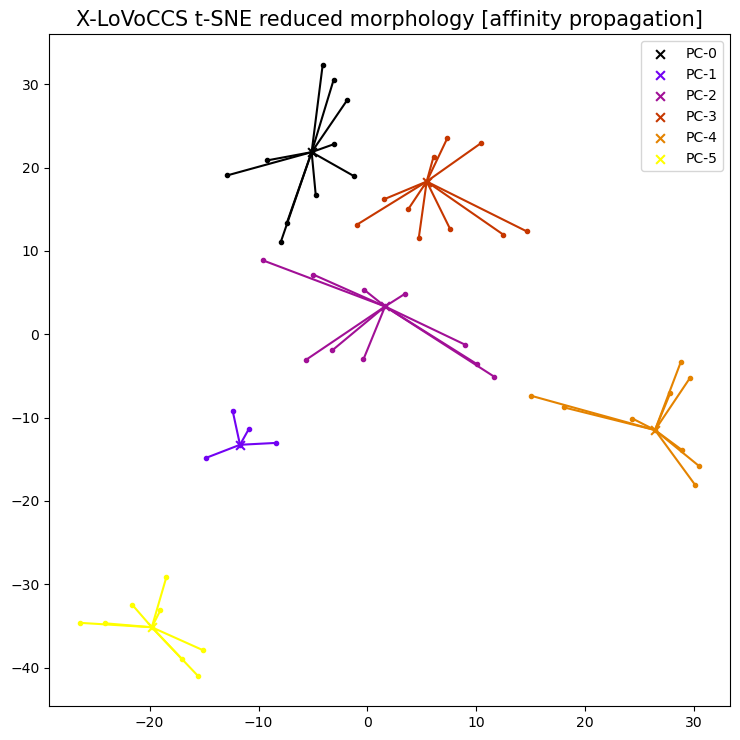

In [27]:
plt.figure(figsize=(7.5, 7.5))

colors = plt.cycler("color", plt.cm.gnuplot(np.linspace(0, 1, tsne_aff_num_pnt_clst)))

for k, col in zip(range(tsne_aff_num_pnt_clst), colors):
    class_members = tsne_aff_pnt_membership == k
    cluster_center = tsne_reduced[aff_pr_tsne.cluster_centers_indices_[k]]
    plt.scatter(tsne_reduced[class_members, 0], tsne_reduced[class_members, 1], color=col["color"], marker=".")
    plt.scatter(cluster_center[0], cluster_center[1], s=40, color=col["color"], marker="x", label="PC-"+str(k))
    
    for x in tsne_reduced[class_members]:
        plt.plot([cluster_center[0], x[0]], [cluster_center[1], x[1]], color=col["color"])

plt.title('X-LoVoCCS t-SNE reduced morphology [affinity propagation]', fontsize=15)

plt.legend()
plt.tight_layout()
plt.show()

### K-means clustering - tSNE embedding

In [28]:
kmeans_tsne_num_clust = 3

kmeans_tsne = KMeans(kmeans_tsne_num_clust)
kmeans_tsne = kmeans_tsne.fit(tsne_reduced)

In [29]:
tsne_kmeans_num_members = np.unique(kmeans_tsne.labels_, return_counts=True)[1]
tsne_kmeans_pnt_membership = kmeans_tsne.labels_

for clst_ind in range(0, kmeans_tsne_num_clust):
    print('PC-'+str(clst_ind), '[{n} members]'.format(n=tsne_kmeans_num_members[clst_ind]))

PC-0 [13 members]
PC-1 [14 members]
PC-2 [30 members]


In [30]:
for clst_ind in range(0, kmeans_tsne_num_clust):
    cur_memb_inds = np.argwhere(tsne_kmeans_pnt_membership == clst_ind).flatten()
    cur_lov_names = rel_names[cur_memb_inds]
    print("PC-" + str(clst_ind))
    for lov_name in cur_lov_names:
        print(lov_name)
    print('')

PC-0
LoVoCCS-22
LoVoCCS-24
LoVoCCS-35
LoVoCCS-39
LoVoCCS-41A
LoVoCCS-45
LoVoCCS-48A
LoVoCCS-49
LoVoCCS-51
LoVoCCS-60B
LoVoCCS-75
LoVoCCS-93A
LoVoCCS-131

PC-1
LoVoCCS-9
LoVoCCS-11
LoVoCCS-41B
LoVoCCS-46B
LoVoCCS-46C
LoVoCCS-46A
LoVoCCS-48B
LoVoCCS-60A
LoVoCCS-61
LoVoCCS-65
LoVoCCS-66B
LoVoCCS-93B
LoVoCCS-121
LoVoCCS-123

PC-2
LoVoCCS-1
LoVoCCS-2
LoVoCCS-5
LoVoCCS-7
LoVoCCS-10
LoVoCCS-12
LoVoCCS-13
LoVoCCS-14
LoVoCCS-15
LoVoCCS-18
LoVoCCS-21
LoVoCCS-26
LoVoCCS-27
LoVoCCS-28
LoVoCCS-29
LoVoCCS-30
LoVoCCS-31
LoVoCCS-42
LoVoCCS-58
LoVoCCS-63
LoVoCCS-66A
LoVoCCS-67
LoVoCCS-74
LoVoCCS-80
LoVoCCS-85
LoVoCCS-89
LoVoCCS-94
LoVoCCS-98
LoVoCCS-99
LoVoCCS-119



We visualise the point cluster memberships identified by K-means:

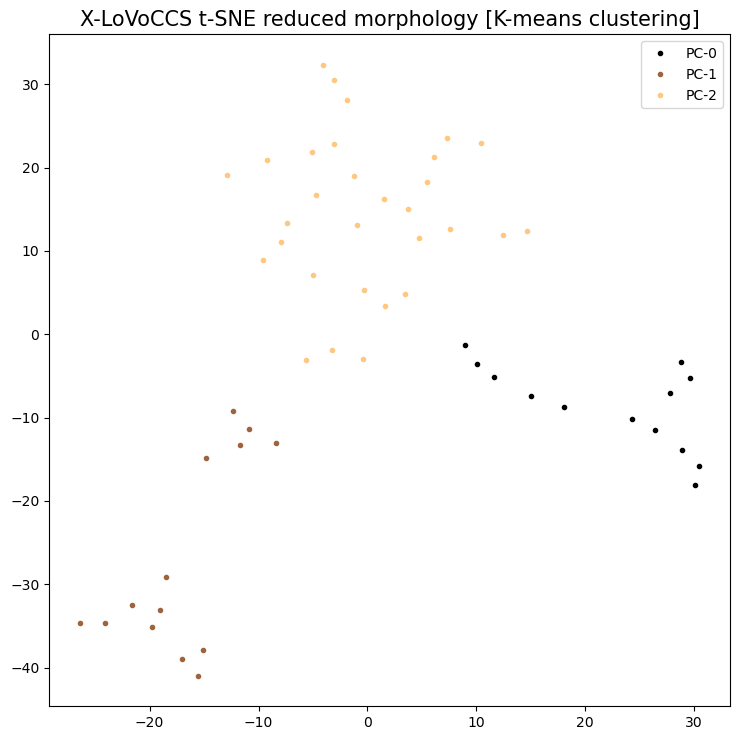

In [31]:
plt.figure(figsize=(7.5, 7.5))

colors = plt.cycler("color", plt.cm.copper(np.linspace(0, 1, kmeans_tsne_num_clust)))
for k, col in zip(range(kmeans_tsne_num_clust), colors):
    cur_sel = np.argwhere(tsne_kmeans_pnt_membership == k).flatten()

    plt.plot(tsne_reduced[cur_sel, 0], tsne_reduced[cur_sel, 1], '.', color=col['color'], label='PC-'+str(k))

plt.title('X-LoVoCCS t-SNE reduced morphology [K-means clustering]', fontsize=15)
plt.legend()
plt.tight_layout()
plt.show()